In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re

In [2]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [3]:

ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250416_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
        #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 73 directories


In [4]:
from parse_levels import filter_folder_info

In [5]:
folder_info = ori_results

In [6]:

search_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 73 directories


In [7]:
r1_flat = filter_folder_info(folder_info, [
   ('levels', 1),  # level 125 stands for using pseudo-code (1), text (2), and paper (5)
   ('runner', 'bon'),
   ('model', 'deepseek-r1'),
   ('n_hypotheses', 50)
])
o3_flat = filter_folder_info(folder_info, [
   ('levels', 1), 
   ('runner', 'bon'),
   ('model', 'o3-mini'),
   ('n_hypotheses', 50)
])
# r1_aide = filter_folder_info(folder_info, [
#    ('levels', 1), 
#    ('runner', 'aide'),
#    ('model', 'deepseek-r1'),
#    # ('n_hypotheses', 3)
# ])
# o3_aide = filter_folder_info(folder_info, [
#    ('levels', 1), 
#    ('runner', 'aide'),
#    ('model', 'o3-mini'),
#    # ('n_hypotheses', 3)
# ])

In [8]:
print(f"r1_flat: {len(r1_flat)}")
print(f"o3_flat: {len(o3_flat)}")

r1_flat: 18
o3_flat: 18


In [9]:
r1_aide = filter_folder_info(search_results, [
   ('levels', 1), 
   ('runner', 'aide'),
   ('model', 'deepseek-r1'),
   ('n_hypotheses', 1)
])
o3_aide = filter_folder_info(search_results, [
   ('levels', 1), 
   ('runner', 'aide'),
   ('model', 'o3-mini'),
   ('n_hypotheses', 1)
])
r1_bon = filter_folder_info(search_results, [
   ('levels', 1),
   ('runner', 'bon'),
   ('model', 'deepseek-r1'),
   ('n_hypotheses', 3)
])
o3_bon = filter_folder_info(search_results, [
   ('levels', 1),
   ('runner', 'bon'),
   ('model', 'o3-mini'),
   ('n_hypotheses', 3)
])

In [10]:
print(f"r1_aide: {len(r1_aide)}")
print(f"r1_bon: {len(r1_bon)}")
print(f"o3_bon: {len(o3_bon)}")
print(f"o3_aide: {len(o3_aide)}")

r1_aide: 18
r1_bon: 18
o3_bon: 18
o3_aide: 18


In [11]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [12]:
r1_bon_search = process_metrics(r1_bon)
o3_bon_search = process_metrics(o3_bon)
r1_aide_search = process_metrics(r1_aide)
o3_aide_search = process_metrics(o3_aide)

In [13]:
r1_flat_search = process_metrics(r1_flat)
o3_flat_search = process_metrics(o3_flat)


In [14]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        if record_num in results:
            results[record_num] = min(results[record_num], v['metrics']['train_time'].min())
        else:
            results[record_num] = v['metrics']['train_time'].min()
        # results[record_num] = v['metrics']['train_time'].tolist()
    return results

# r1_flat_search_result = convert_to_dict(r1_flat_search)
# o3_flat_search_result = convert_to_dict(o3_flat_search)
r1_bon_search_result = convert_to_dict(r1_bon_search)
o3_bon_search_result = convert_to_dict(o3_bon_search)
r1_aide_search_result = convert_to_dict(r1_aide_search)
o3_aide_search_result = convert_to_dict(o3_aide_search)

r1_flat_search_result = convert_to_dict(r1_flat_search)
o3_flat_search_result = convert_to_dict(o3_flat_search)
# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# r1_aide_l12_results = convert_to_dict(r1_aide_dummy_no_knowledge_l12)
# # o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)
# o3_aide_l12_results = convert_to_dict(o3_aide_dummy_no_knowledge_l12)

In [15]:

human_train_time_dict = {
    1: 2968348,
    2: 2209926,
    3: 1386147,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [16]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [17]:
# r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
# r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
# r1_aide_l12_gap_in_percentage = compute_gap_in_percentage(r1_aide_l12_results)
# # o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
# o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)
# o3_aide_l12_gap_in_percentage = compute_gap_in_percentage(o3_aide_l12_results)
r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_search_result)
r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_search_result)
o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_search_result)
o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_search_result)

r1_flat_gap_in_percentage = compute_gap_in_percentage(r1_flat_search_result)
o3_flat_gap_in_percentage = compute_gap_in_percentage(o3_flat_search_result)


In [18]:
# delete the 6th record cause its upgrade pytorch which the agent cannot handle
del r1_bon_gap_in_percentage[6]
del r1_aide_gap_in_percentage[6]
del o3_bon_gap_in_percentage[6]
del o3_aide_gap_in_percentage[6]
del r1_flat_gap_in_percentage[6]
del o3_flat_gap_in_percentage[6]


In [19]:
r1_flat_gap_in_percentage = {str(k): v for k, v in r1_flat_gap_in_percentage.items()}
o3_flat_gap_in_percentage = {str(k): v for k, v in o3_flat_gap_in_percentage.items()}

In [20]:
r1_bon_gap_in_percentage = {str(k): v for k, v in r1_bon_gap_in_percentage.items()}
r1_aide_gap_in_percentage = {str(k): v for k, v in r1_aide_gap_in_percentage.items()}
o3_bon_gap_in_percentage = {str(k): v for k, v in o3_bon_gap_in_percentage.items()}
o3_aide_gap_in_percentage = {str(k): v for k, v in o3_aide_gap_in_percentage.items()}


In [21]:
o3_bon_gap_in_percentage['3'] = 0
o3_aide_gap_in_percentage['2'] = 0
r1_aide_gap_in_percentage['2'] = 0
# ignore some summarizer mistakes 

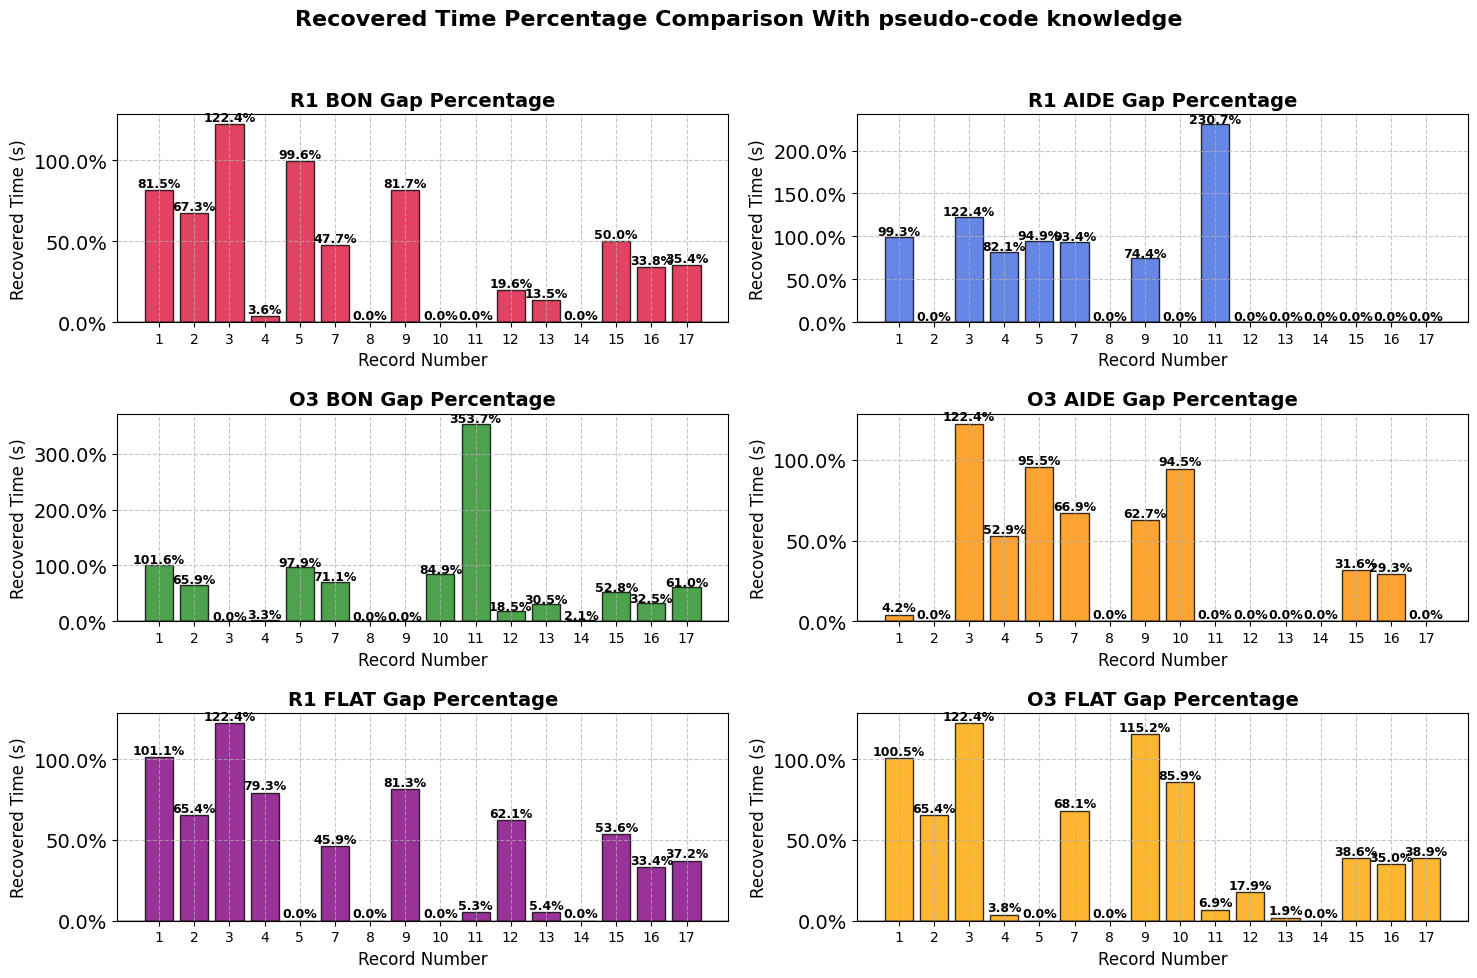

In [23]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
    (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
    (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
    (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange'),
    (r1_flat_gap_in_percentage, "R1 FLAT Gap Percentage", 'purple'),
    (o3_flat_gap_in_percentage, "O3 FLAT Gap Percentage", 'orange')
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(3, 2, figsize=(15, 10))
axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items(), key=lambda x: int(x[0]))
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(range(len(keys)), values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(range(len(keys)))
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison With pseudo-code knowledge', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()